# Edge Transformer — Multi-N Curriculum Training

One set of weights trained on several graph sizes in **random cycle order**.
Because `proj_in = Linear(4, d)` the policy is fully size-agnostic, so after
training on `{5, 10, 13, 24}` we can probe it on unseen sizes like `{7, 12, 25}`
and see whether it has generalised.

Checkpoints saved to `./checkpoints_edge_multi_{checker_name}/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from turan_env_c import (
    CEnv,
    CHECKER_C3, CHECKER_C4, CHECKER_C3C4,
    CHECKER_K23, CHECKER_THETA123, CHECKER_BULL,
    CHECKER_BOWTIE, CHECKER_K4,
)
from edge_transformer_policy import EdgeTransformerPolicy
from ppo_edge import CFG, train_multi_n_random, load_checkpoint, run_episodes
from torch.optim import Adam

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090


## Pick your setup
Edit the two cells below, then run all.

In [2]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
CHECKER  = CHECKER_C3C4   # CHECKER_C3 | CHECKER_C4 | CHECKER_K4 | ...

TRAIN_NS = [20, 10, 13, 24]   # sizes the policy is trained on
EVAL_NS  = [7,11,12,25]       # held-out sizes — never seen during training

N_CYCLES         = 1         # how many times to cycle through TRAIN_NS (in random order)
STEPS_PER_N      = 3_000_000 # PPO steps per n per cycle

RESUME   = '/root/backtoRL/NaiveTrainingV2/checkpoints_edge_c3c4_n20/best.pt'             # e.g. './checkpoints_edge_multi_c3/final.pt'
TRAIN    = False

# Policy architecture
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2
# ──────────────────────────────────────────────────────────────────────────────

CHECKER_NAMES = {
    CHECKER_C3:       'c3',
    CHECKER_C4:       'c4',
    CHECKER_C3C4:     'c3c4',
    CHECKER_K23:      'k23',
    CHECKER_THETA123: 'theta123',
    CHECKER_BULL:     'bull',
    CHECKER_BOWTIE:   'bowtie',
    CHECKER_K4:       'k4',
}
checker_name = CHECKER_NAMES[CHECKER]
ckpt_dir     = f'./checkpoints_edge_multi_{checker_name}'

def mantel_bound(n):
    """ex(n, C3) = floor(n^2/4)  — rough reference for other checkers too."""
    return n * n // 4

print(f"Checker   : {checker_name}  (id={CHECKER})")
print(f"Train NS  : {TRAIN_NS}")
print(f"Eval  NS  : {EVAL_NS}")
print(f"Cycles    : {N_CYCLES}  x  {STEPS_PER_N/1e6:.1f}M steps/n")
print(f"Total     : ~{N_CYCLES * len(TRAIN_NS) * STEPS_PER_N / 1e6:.0f}M steps")
print(f"Ckpt dir  : {ckpt_dir}")
print(f"Policy    : d={D_MODEL}  heads={N_HEADS}  layers={N_LAYERS}")

Checker   : c3c4  (id=2)
Train NS  : [20, 10, 13, 24]
Eval  NS  : [7, 11, 12, 25]
Cycles    : 1  x  3.0M steps/n
Total     : ~12M steps
Ckpt dir  : ./checkpoints_edge_multi_c3c4
Policy    : d=64  heads=4  layers=2


In [3]:
cfg = {**CFG}

cfg['checker_id']        = CHECKER
cfg['checkpoint_dir']    = ckpt_dir
cfg['total_steps_per_n'] = STEPS_PER_N

# Policy architecture
cfg['d_model']  = D_MODEL
cfg['n_heads']  = N_HEADS
cfg['n_layers'] = N_LAYERS

# ── PPO hyperparams ──
cfg['lr']          = 1e-5
cfg['ent_coef']    = 0.08
cfg['num_envs']    = 2048
cfg['n_steps']     = 64
cfg['batch_size']  = 2048
cfg['log_interval']  = 20
cfg['save_interval'] = 100
cfg['seed']          = 42

for k, v in cfg.items():
    print(f"  {k:22s} = {v}")

  n                      = 20
  num_envs               = 2048
  checker_id             = 2
  n_steps                = 64
  n_epochs               = 10
  batch_size             = 2048
  lr                     = 1e-05
  gamma                  = 0.99
  gae_lambda             = 0.95
  clip_eps               = 0.2
  vf_coef                = 0.5
  ent_coef               = 0.08
  max_grad_norm          = 0.5
  total_steps            = 20000000
  device                 = cuda
  log_interval           = 20
  save_interval          = 100
  checkpoint_dir         = ./checkpoints_edge_multi_c3c4
  total_steps_per_n      = 3000000
  d_model                = 64
  n_heads                = 4
  n_layers               = 2
  seed                   = 42


## Env sanity + benchmark

In [4]:
for n in TRAIN_NS:
    env = CEnv(n=n, num_envs=cfg['num_envs'], checker_id=CHECKER)
    obs = env.reset()
    E   = n * (n-1) // 2
    print(f"n={n:2d}  obs={obs.shape}  E={E:4d}  bound~{mantel_bound(n)}")
    env.close()

# Run timing benchmark on largest training size
env = CEnv(n=max(TRAIN_NS), num_envs=cfg['num_envs'], checker_id=CHECKER)
env.benchmark(steps=200)
env.close()

p = EdgeTransformerPolicy(D_MODEL, N_HEADS, N_LAYERS)
print(f"\nPolicy params: {sum(x.numel() for x in p.parameters()):,}")
del p

n=20  obs=(2048, 190)  E= 190  bound~100
n=10  obs=(2048, 45)  E=  45  bound~25
n=13  obs=(2048, 78)  E=  78  bound~42
n=24  obs=(2048, 276)  E= 276  bound~144
200 steps x 2048 envs in 0.22s
  1,842,806 steps/sec
  1.84M steps/sec

Policy params: 71,043


## Train

In [5]:
device = torch.device(cfg['device'])

if TRAIN:
    if RESUME:
        policy, optimizer, loaded_cfg, _, global_step, _ = load_checkpoint(RESUME, device=str(device))
        cfg.update({k: loaded_cfg[k] for k in ('d_model', 'n_heads', 'n_layers')})
        print(f"Resuming from {RESUME}  (global_step={global_step:,})")
    else:
        policy = EdgeTransformerPolicy(
            d_model  = cfg['d_model'],
            n_heads  = cfg['n_heads'],
            n_layers = cfg['n_layers'],
        ).to(device)
        policy    = torch.compile(policy)
        optimizer = Adam(policy.parameters(), lr=cfg['lr'])
        global_step = 0
        print(f"Fresh policy — {sum(p.numel() for p in policy.parameters()):,} params")

    policy, history = train_multi_n_random(
        train_ns    = TRAIN_NS,
        policy      = policy,
        optimizer   = optimizer,
        cfg         = cfg,
        n_cycles    = N_CYCLES,
        global_step = global_step,
    )
else:
    assert RESUME and os.path.exists(RESUME), \
        f"Set RESUME to a valid checkpoint path when TRAIN=False (got: {RESUME})"
    policy, _, cfg, _, _, _ = load_checkpoint(RESUME)
    policy.eval()
    history = []
    print(f"Loaded checkpoint: {RESUME} (training skipped)")

loaded /root/backtoRL/NaiveTrainingV2/checkpoints_edge_c3c4_n20/best.pt  iter=254  steps=16,646,144  best=42.25
Loaded checkpoint: /root/backtoRL/NaiveTrainingV2/checkpoints_edge_c3c4_n20/best.pt (training skipped)


## Training curves — per n

In [6]:
if not history:
    print("No history (loaded from checkpoint, skipping curves)")
else:
    by_n = defaultdict(list)
    for h in history:
        by_n[h['n']].append(h)

    colors    = plt.cm.tab10.colors
    color_map = {n: colors[i % 10] for i, n in enumerate(TRAIN_NS)}

    def smooth(vals, frac=0.07):
        w = max(1, int(len(vals) * frac))
        return np.convolve(vals, np.ones(w) / w, mode='valid'), w

    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    fig.patch.set_facecolor('#f5f5f5')

    for ax in axes.flat:
        ax.set_facecolor('#ffffff')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
        ax.tick_params(labelsize=10)

    # ── Return per n ──────────────────────────────────────────────────────────
    ax = axes[0, 0]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['mean_ret'] for r in rows]
        ax.plot(xs, ys, alpha=0.15, color=color_map[n], linewidth=0.8)
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, label=f'n={n} (bound~{mantel_bound(n)})',
                color=color_map[n], linewidth=2.5)
    ax.set_title('Return per n', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.8)

    # ── Return / Mantel bound ─────────────────────────────────────────────────
    ax = axes[0, 1]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['mean_ret'] / mantel_bound(n) for r in rows]
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, label=f'n={n}', color=color_map[n], linewidth=2.5)
    ax.axhline(1.0, color='#F44336', linestyle='--', linewidth=2, label='Mantel bound')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title('Return / Mantel bound', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.8)

    # ── Policy loss ───────────────────────────────────────────────────────────
    ax = axes[0, 2]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['pg'] for r in rows]
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, label=f'n={n}', color=color_map[n], linewidth=2)
    ax.set_title('Policy Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.8)

    # ── Entropy ───────────────────────────────────────────────────────────────
    ax = axes[1, 0]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['ent'] for r in rows]
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, label=f'n={n}', color=color_map[n], linewidth=2)
    ax.set_title('Entropy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.8)

    # ── FPS ───────────────────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax.scatter(
        [h['global_step'] / 1e6 for h in history],
        [h['fps'] for h in history],
        s=6, alpha=0.5,
        c=[color_map[h['n']] for h in history])
    ax.set_title('FPS  (colour = n)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)

    # ── Best return vs bound bar chart ────────────────────────────────────────
    ax = axes[1, 2]
    ns_sorted   = sorted(by_n.keys())
    best_rets   = [max(r['mean_ret'] for r in by_n[n]) for n in ns_sorted]
    bounds_plot = [mantel_bound(n) for n in ns_sorted]
    x_pos = np.arange(len(ns_sorted))
    ax.bar(x_pos, bounds_plot, label='Mantel bound',
           color='#ef9a9a', edgecolor='#F44336', linewidth=2, zorder=1)
    ax.bar(x_pos, best_rets, label='Best return',
           color=[color_map[n] for n in ns_sorted], alpha=0.9, zorder=2)
    for i, (br, bd) in enumerate(zip(best_rets, bounds_plot)):
        ax.text(i, br + bd * 0.01, f'{br/bd:.0%}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'n={n}' for n in ns_sorted], fontsize=10)
    ax.set_title('Best return vs Mantel bound', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.8)

    total_steps_plot = history[-1]['global_step'] / 1e6
    fig.suptitle(
        f'EdgeTransformer Multi-N — {checker_name.upper()}   '
        f'train={TRAIN_NS}   {total_steps_plot:.0f}M steps   {N_CYCLES} cycle(s)',
        fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

No history (loaded from checkpoint, skipping curves)


## Evaluate — training sizes and held-out sizes

Run the **same trained policy** deterministically on all sizes (train + eval).
Held-out sizes were never seen during training.

In [10]:
import networkx as nx

policy.eval()
N_EVAL_EPISODES = 5
all_ns = sorted(set(TRAIN_NS) | set(EVAL_NS))

results = {}
print(f"{'n':>4}  {'seen':>6}  {'best_edges':>10}  {'bound':>6}  {'%bound':>7}")
print('-' * 42)
for n in all_ns:
    seen  = 'train' if n in TRAIN_NS else 'HELD-OUT'
    adjs  = run_episodes(policy, {**cfg, 'n': n}, n_episodes=N_EVAL_EPISODES, deterministic=True)
    edges = [int(adj.sum()) // 2 for adj in adjs]
    best  = max(edges)
    bound = mantel_bound(n)
    pct   = best / bound * 100
    results[n] = dict(best=best, bound=bound, pct=pct, adjs=adjs, edges=edges)
    print(f"{n:>4}  {seen:>8}  {best:>10}  {bound:>6}  {pct:>6.1f}%")

   n    seen  best_edges   bound   %bound
------------------------------------------


   7  HELD-OUT           7      12    58.3%
  10     train          10      25    40.0%
  11  HELD-OUT          13      30    43.3%
  12  HELD-OUT          18      36    50.0%
  13     train          20      42    47.6%
  20     train          34     100    34.0%
  24     train          35     144    24.3%
  25  HELD-OUT          39     156    25.0%


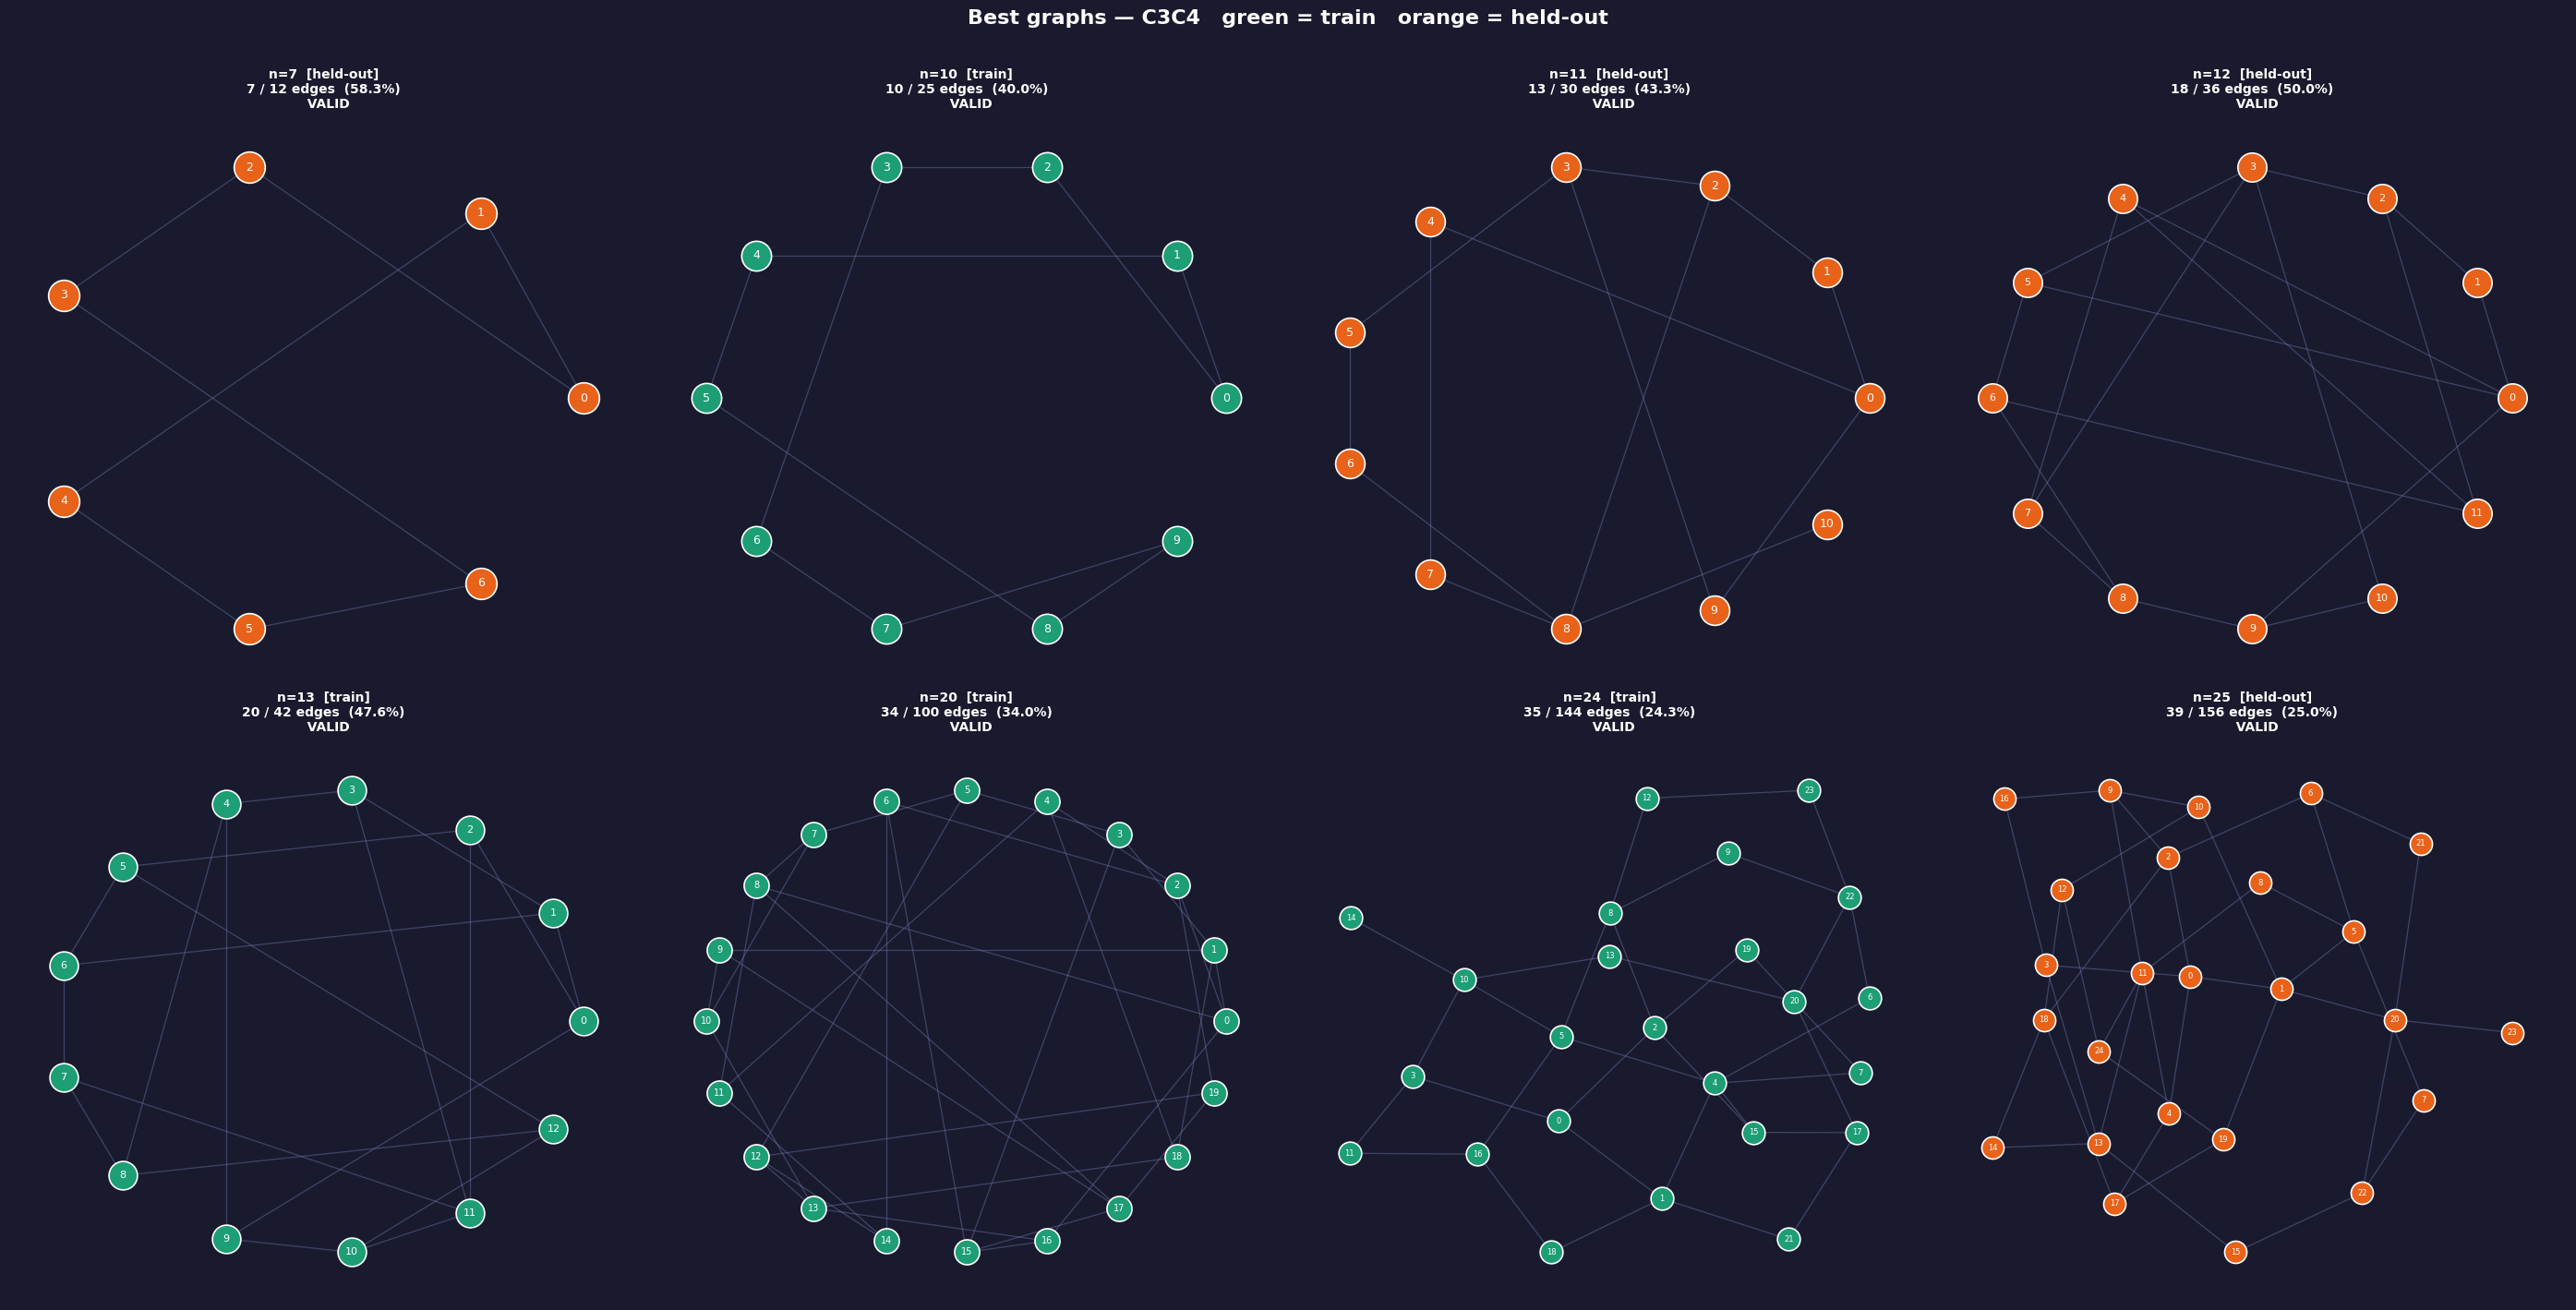

In [11]:
from checkers import (
    C3Checker, C4Checker, C3C4Checker,
    K23Checker, Theta123Checker, BullChecker, BowTieChecker,
)

CHECKER_CLASS_MAP = {
    CHECKER_C3:       C3Checker,
    CHECKER_C4:       C4Checker,
    CHECKER_C3C4:     C3C4Checker,
    CHECKER_K23:      K23Checker,
    CHECKER_THETA123: Theta123Checker,
    CHECKER_BULL:     BullChecker,
    CHECKER_BOWTIE:   BowTieChecker,
}

def verify_graph(adj, checker_id, n):
    """Return list of violating edges, empty = valid."""
    if checker_id not in CHECKER_CLASS_MAP:
        return None   # unknown checker, skip
    checker = CHECKER_CLASS_MAP[checker_id](n)
    bad = []
    for u in range(n):
        for v in range(u + 1, n):
            if adj[u][v]:
                adj[u][v] = adj[v][u] = 0
                if checker.check(adj, u, v):
                    bad.append((u, v))
                adj[u][v] = adj[v][u] = 1
    return bad

def best_layout(G, n):
    if n <= 20:
        return nx.circular_layout(G)
    elif n <= 60:
        return nx.kamada_kawai_layout(G)
    return nx.spring_layout(G, seed=42, k=2.5 / n**0.5, iterations=60)

# ── Draw grids ────────────────────────────────────────────────────────────────
n_cols = min(len(all_ns), 4)
n_rows = (len(all_ns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(7 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#1a1a2e')
axes = np.array(axes).flatten()

for idx, n in enumerate(all_ns):
    ax  = axes[idx]
    r   = results[n]
    adj = r['adjs'][np.argmax(r['edges'])].copy()

    # Verify
    violations = verify_graph(adj.astype(bool), CHECKER, n)
    if violations is None:
        validity = "(no checker)"
    elif violations:
        validity = f"  INVALID ({len(violations)} violations)"
    else:
        validity = "  VALID"

    G   = nx.from_numpy_array(adj)
    pos = best_layout(G, n)

    ax.set_facecolor('#1a1a2e')
    is_train  = n in TRAIN_NS
    node_col  = '#1D9E75' if is_train else '#E8621A'
    node_size = max(60, 700 - n * 16)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#7c83bc', alpha=0.4, width=0.9)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_col,
                           node_size=node_size, linewidths=1.2, edgecolors='white')
    if n <= 25:
        nx.draw_networkx_labels(G, pos, ax=ax,
                                font_color='white', font_size=max(6, 10 - n // 6))

    label = 'train' if is_train else 'held-out'
    ax.set_title(
        f"n={n}  [{label}]\n"
        f"{r['best']} / {r['bound']} edges  ({r['pct']:.1f}%)\n"
        f"{validity}",
        fontsize=10, fontweight='bold', color='white', pad=8)
    ax.axis('off')

for ax in axes[len(all_ns):]:
    ax.set_facecolor('#1a1a2e')
    ax.axis('off')

fig.suptitle(
    f"Best graphs — {checker_name.upper()}   "
    f"green = train   orange = held-out",
    fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()